In [1]:
import os
import h5py
import pandas as pd
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

In [2]:
original_df = pd.read_csv('processed_data/expanded_df_formatted.csv')
h5_path = 'processed_data/expanded_spectrograms.h5'

### Using pixel averages to find which datapoints are mostly empty

In [3]:
spec_averages = np.empty(len(original_df))
chunk_size = 10000

with h5py.File(h5_path, 'r') as src_h5:
    src_dset = src_h5['spectrograms']
    
    for start in range(0, len(original_df), chunk_size):
        if start > 0 and start % (chunk_size * 3) == 0:
            print(f'Finished {start} spectrograms in total.')

        end = min(start + chunk_size, len(original_df))
        chunk = src_dset[start:end]
        spec_averages[start:end] = chunk.mean(axis=(1, 2))

Finished 30000 spectrograms in total.
Finished 60000 spectrograms in total.
Finished 90000 spectrograms in total.


In [49]:
with open('processed_data/spectrogram_averages.npy', 'wb') as f:
    np.save(f, spec_averages)

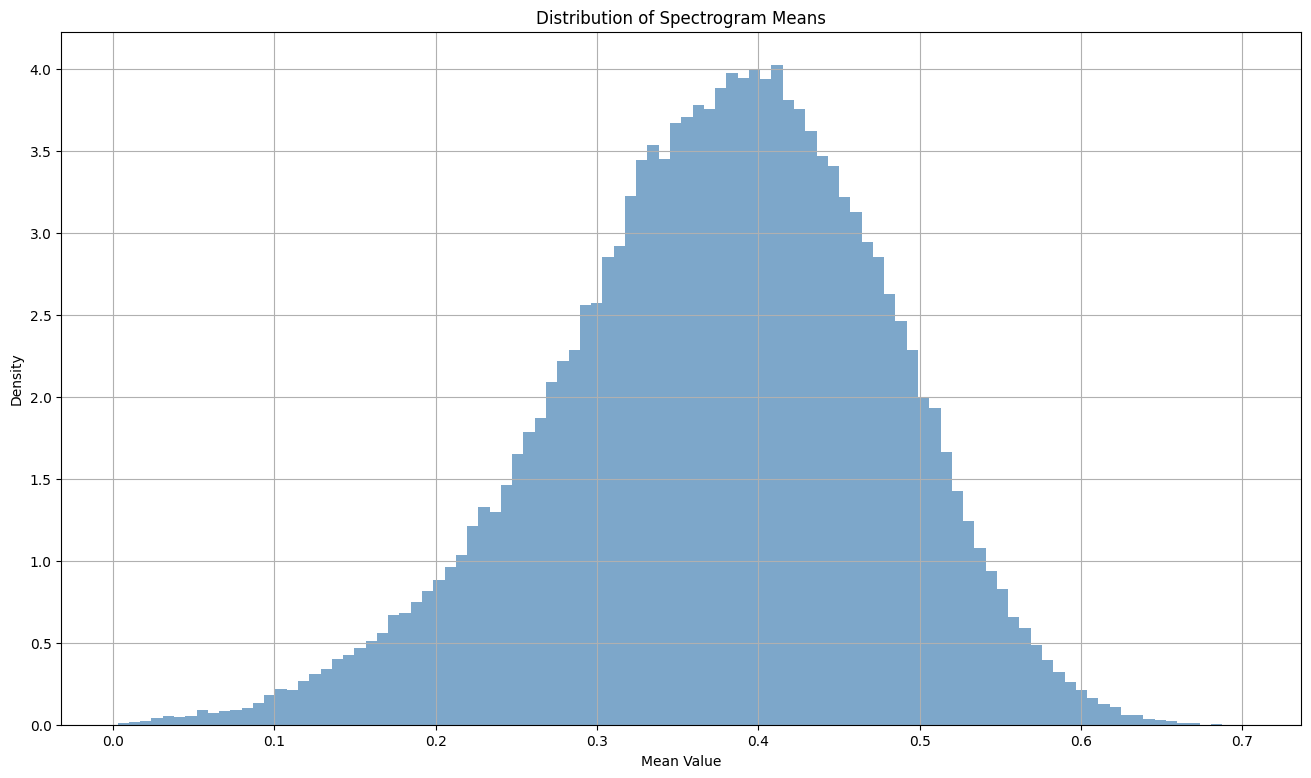

In [4]:
plt.figure(figsize=(16, 9))
plt.hist(spec_averages, bins=100, density=True, alpha=0.7, color='steelblue')
plt.title("Distribution of Spectrogram Means")
plt.xlabel("Mean Value")
plt.ylabel("Density")
plt.grid(True)
plt.show()

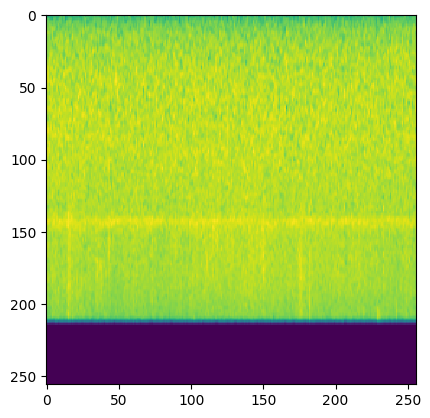

In [5]:
with h5py.File(h5_path, 'r') as src_h5:
    src_dset = src_h5['spectrograms']
    spec = src_dset[np.argmax(spec_averages)]

    plt.imshow(spec, interpolation='none')
    plt.show()

In [6]:
sorted_original_df = original_df.loc[np.argsort(spec_averages)]
sorted_original_df

,working_df_idx,samplename,chunk_id,filepath,primary_label,secondary_labels,matches_primary,matches_secondary,top_class
110982,27744,yeofly1-XC328921-1,1,/kaggle/input/birdclef-2025/train_audio/yeofly...,yeofly1,[''],False,False,tribun1
91363,23025,trokin-iNat162152-0,0,/kaggle/input/birdclef-2025/train_audio/trokin...,trokin,[''],False,False,sthbrf5
80651,20463,speowl1-XC233090-2,2,/kaggle/input/birdclef-2025/train_audio/speowl...,speowl1,[''],False,False,scaqua
110981,27744,yeofly1-XC328921-0,0,/kaggle/input/birdclef-2025/train_audio/yeofly...,yeofly1,[''],False,False,scbtan1
80652,20463,speowl1-XC233090-3,3,/kaggle/input/birdclef-2025/train_audio/speowl...,speowl1,[''],False,False,scaqua
...,...,...,...,...,...,...,...,...,...
57682,14164,paltan1-XC525435-1,1,/kaggle/input/birdclef-2025/train_audio/paltan...,paltan1,[''],False,False,gabfru1
87229,22055,strowl1-XC351411-1,1,/kaggle/input/birdclef-2025/train_audio/strowl...,strowl1,[''],False,False,azukin1
46726,11667,grnkin-XC957618-3,3,/kaggle/input/birdclef-2025/train_audio/grnkin...,grnkin,[''],False,False,rebfly
88726,22380,thlsch3-XC114701-1,1,/kaggle/input/birdclef-2025/train_audio/thlsch...,thlsch3,[''],False,False,thitin1


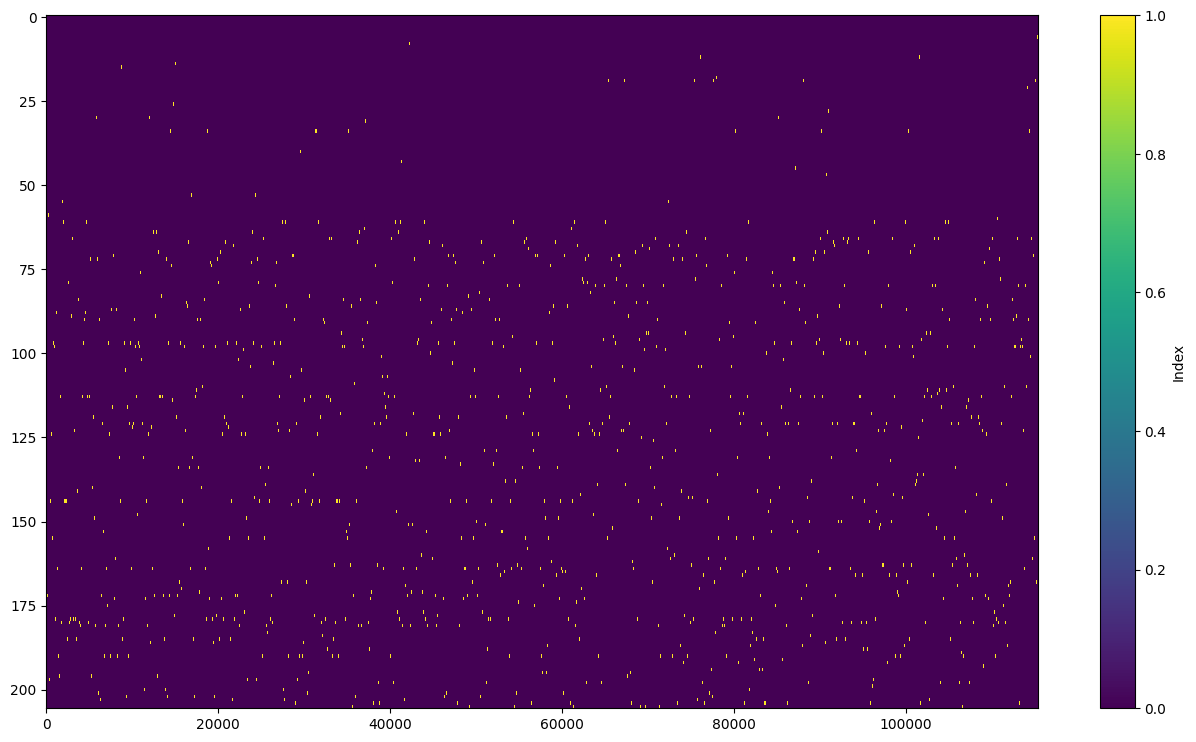

In [7]:
recency_array = np.empty((sorted_original_df['primary_label'].nunique(), len(sorted_original_df)))

for i, (_, matching_indices) in enumerate(sorted_original_df.groupby('primary_label').indices.items()):
    recency_array[i][matching_indices] = 1

# for i, label in enumerate(sorted_original_df['primary_label'].unique()):
#     matching_indices = (sorted_original_df['primary_label'].to_numpy() == label).nonzero()[0]
#     recency_array[i][matching_indices] = 1

plt.figure(figsize=(16, 9))
plt.imshow(recency_array, aspect='auto', interpolation='none')
plt.colorbar(label='Index')
plt.show()

In [44]:
def plot_filtered_class_proportions(original_df, filtered_df, label_col='primary_label'):
    original_counts = original_df[label_col].value_counts().sort_index()
    filtered_counts = filtered_df[label_col].value_counts().sort_index()


    all_labels = sorted(original_counts.index.union(filtered_counts.index))
    original_counts = original_counts.reindex(all_labels, fill_value=0)
    filtered_counts = filtered_counts.reindex(all_labels, fill_value=0)

    proportions = filtered_counts / original_counts.replace(0, 1)

    plt.figure(figsize=(20, 6))
    plt.bar(all_labels, proportions, color='steelblue')
    plt.xticks(rotation=90, fontsize=8)
    plt.ylabel("Proportion in Filtered vs Original")
    plt.title("Class Retention in Filtered Dataset Relative to Original")
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

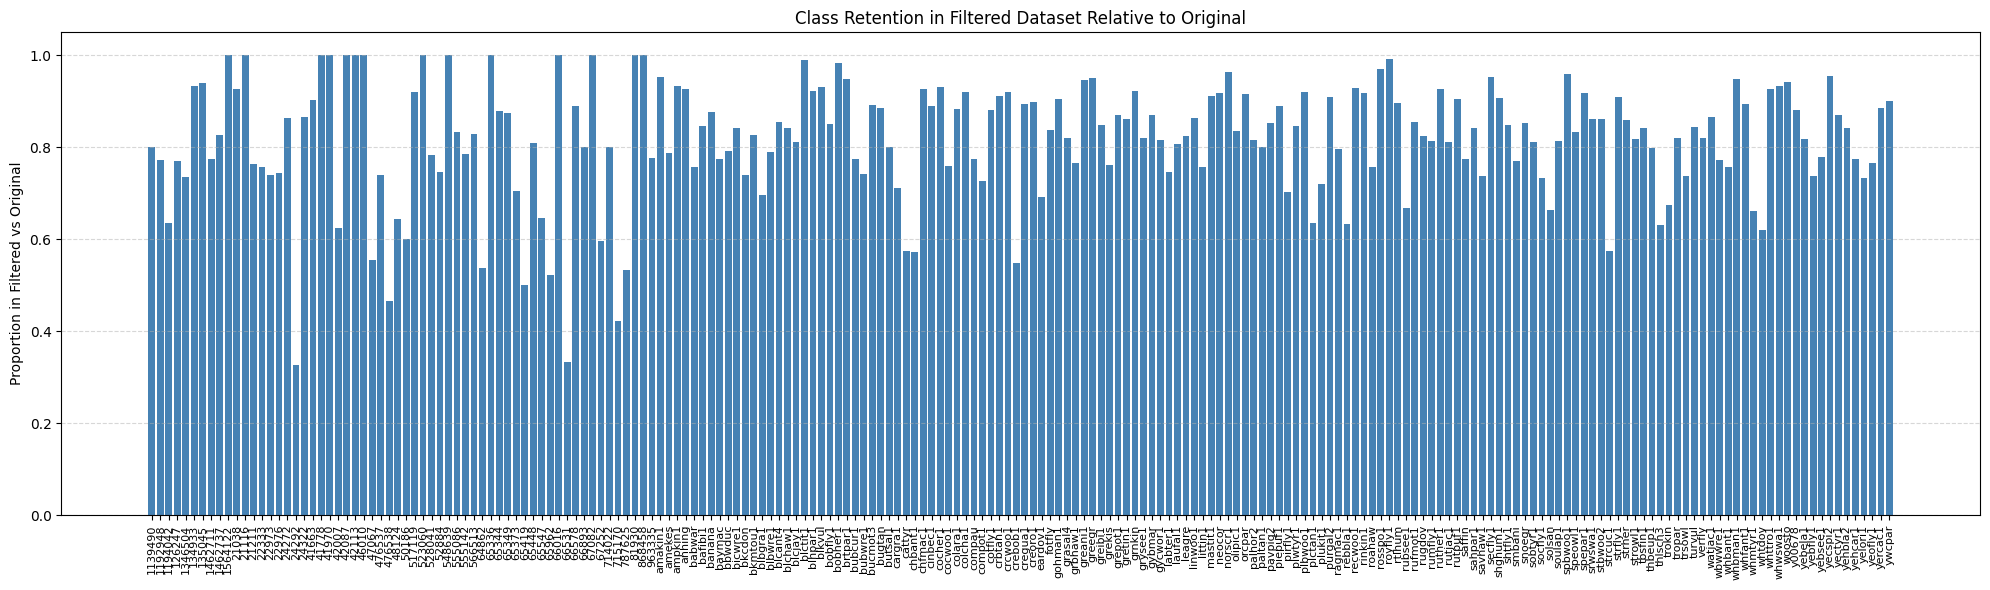

In [45]:
filtered_df = sorted_original_df.loc[np.where(spec_averages >= np.percentile(spec_averages, 20))[0]]
plot_filtered_class_proportions(sorted_original_df, filtered_df)